# Fase 2 — Feature Engineering

**Proyecto:** modelo de riesgo crediticio · **Entrada:** `Base_de_datos_limpia.csv`

---

## Alcance y arquitectura de este notebook

Este notebook **documenta y valida** la Fase 2. La lógica está implementada en
`ft_engineering.py`

**Por qué importar y no copiar.** Si el notebook tuviera su propia copia de las funciones,
cualquier corrección en el script dejaría de reflejarse aquí y acabaríamos con dos versiones
divergentes de la misma transformación. El script es la única fuente de verdad es el que se
ejecutará en producción en la Fase 4—y el notebook aporta lo que un `.py` no puede es decir la
justificación de cada decisión y la inspección visual de los resultados.



| Paso | Contenido |
|---|---|
| 1 | Carga y configuración |
| 2 | Exclusión de variables con fuga de información |
| 3 | Partición de datos (estratificada y temporal) |
| 4 | Atributos derivados |
| 5 | Binning y Weight of Evidence |
| 6 | Codificación y escalado |
| 7 | Validación del aporte de las características |

## Partición antes que transformación

Si los cortes de binning, los valores WoE o los parámetros de escalado se calculan sobre el
dataset completo, el conjunto de prueba influye en la transformación y deja de medir el desempeño
de forma independiente. Es una forma silenciosa de fuga: las métricas salen mejores de lo que
serán en producción.

Por eso el orden no es negociable: **primero se parte, luego se transforma, y todo estadístico se
ajusta únicamente sobre `train`.**

In [ ]:
# 
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import ft_engineering as fe

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

print("Raiz del proyecto :", fe.RUTA_RAIZ)
print("Variable objetivo :", fe.TARGET)
print("Semilla           :", fe.SEMILLA)
print("Proporcion de test:", fe.PROPORCION_TEST)

01:49:02 | INFO    | Configuracion cargada desde etl_scripts/src/config.json


Raiz del proyecto : /home/claude/f2
Variable objetivo : Pago_atiempo
Semilla           : 42
Proporcion de test: 0.2


## Carga

Se carga la salida de la Fase 1. La función `cargar_datos()` incluye una condicion de entrada 
si el target trae nulos, deja de ser binario o aparecen duplicados, el script aborta con un error
explícito en lugar de producir una partición silenciosamente incorrecta.

In [2]:
df = fe.cargar_datos()

# Fecha de corte de observacion: se calcula UNA vez sobre el dataset completo.
# Si se derivara de cada particion, train y test usarian referencias distintas
# y la antiguedad del credito no seria comparable entre ambos.
FECHA_CORTE_OBS = df[fe.COLUMNA_FECHA].max()
print("\nUltima fecha observada:", FECHA_CORTE_OBS.date())
df.head(3)

01:49:03 | INFO    | Dataset cargado: 10763 registros x 35 columnas


01:49:03 | INFO    | Tasa de mora global: 4.75% (511 casos)



Ultima fecha observada: 2026-04-26


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo,saldo_principal_era_nulo,saldo_mora_era_nulo,saldo_total_era_nulo,saldo_mora_codeudor_era_nulo,promedio_ingresos_datacredito_era_nulo,sin_historial_crediticio,edad_cliente_corregida,salario_cliente_corregido,tendencia_ingresos_reconstruida,anio_mes_prestamo,vencimiento_teorico,madurez_incompleta,total_otros_prestamos_sospechoso
0,4,2025-01-07 14:40:00,1852560,12,32,Empleado,3500000,1000000,128650,795.0,0,2,0.0,0.0,0.0,0.0,0,0,0,916148.0,Creciente,1,True,False,False,True,False,0,False,False,False,2025-01,2026-01-02 14:40:00,False,0
1,4,2025-01-09 11:18:00,3181080,6,34,Empleado,5000000,2000000,441817,796.0,0,7,0.0,0.0,0.0,0.0,0,0,0,4473774.0,Creciente,1,True,False,False,True,False,0,False,False,False,2025-01,2025-07-08 11:18:00,False,0
2,9,2024-12-26 18:52:00,670200,5,34,Independiente,5000000,2000000,108632,727.0,5,0,0.0,274561.0,274561.0,0.0,2,0,1,NaN,Sin_dato,1,False,False,False,True,True,0,False,False,False,2024-12,2025-05-25 18:52:00,False,0


## Exclusión de variables con fuga de información

`saldo_mora` y `saldo_mora_codeudor` podían estar contaminadas.
el cualse registran después del desembolso son consecuencia y no causa del
impago, y el dato no existe en el momento de originar el crédito.

| Grupo | Variables | Motivo |
|---|---|---|
| Fuga confirmada | `saldo_mora`, `saldo_mora_codeudor` + sus 2 banderas | Registradas tras el desembolso |
| Fuga por precaución | `saldo_total`, `saldo_principal` + sus 2 banderas | Mismo corte del buró; IV 0,018–0,021 |
| No construido | `tiene_mora_previa` | Derivaría de `saldo_mora` |

**El impacto es bajo.** Las cinco variables de mayor Information Value están libres de fuga. La
excluida de mayor peso, `tiene_mora_previa`, ocupaba el sexto lugar con IV débil (0,0884).

In [3]:
df = fe.excluir_variables_con_fuga(df)
print("\nColumnas restantes:", list(df.columns))

01:49:03 | INFO    | Excluidas por fuga confirmada : ['saldo_mora', 'saldo_mora_codeudor', 'saldo_mora_era_nulo', 'saldo_mora_codeudor_era_nulo']


01:49:03 | INFO    | Excluidas por precaucion      : ['saldo_total', 'saldo_principal', 'saldo_total_era_nulo', 'saldo_principal_era_nulo']


01:49:03 | INFO    | Dataset tras exclusion: 10763 registros x 27 columnas



Columnas restantes: ['tipo_credito', 'fecha_prestamo', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'tipo_laboral', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'tendencia_ingresos', 'Pago_atiempo', 'promedio_ingresos_datacredito_era_nulo', 'sin_historial_crediticio', 'edad_cliente_corregida', 'salario_cliente_corregido', 'tendencia_ingresos_reconstruida', 'anio_mes_prestamo', 'vencimiento_teorico', 'madurez_incompleta', 'total_otros_prestamos_sospechoso']


##  Partición de los datos

Se generan **dos particiones** sobre el mismo conjunto, para poder compararlas en la Fase 3.

**Estratificada.** Con 4,75% de mora (ratio ~20:1), una partición aleatoria simple puede dejar el
test con una proporción de positivos muy distinta a la real solo por azar. La estratificación la
fija en ambos lados.

**Temporal.** La Fase 1 documentó que la tasa de mora **no es estable entre cohortes** (de 1,72% a
9,09% según el mes). Un split aleatorio asume que todos los periodos son intercambiables, supuesto
que estos datos no respaldan. Esta partición reproduce la situación real de despliegue.

In [4]:
tr_e, te_e = fe.split_estratificado(df)
met_e = fe.validar_particion('estratificado', tr_e, te_e, len(df))

tr_t, te_t, corte = fe.split_temporal(df)
met_t = fe.validar_particion('temporal', tr_t, te_t, len(df))
print("\nFecha de corte temporal:", corte.date())

01:49:03 | INFO    | [estratificado] train=8610 (mora 4.75%) | test=2153 (mora 4.74%) -> validacion OK


01:49:03 | INFO    | [temporal] train=8609 (mora 5.13%) | test=2154 (mora 3.20%) -> validacion OK



Fecha de corte temporal: 2025-07-12


# CORRECION

`fecha_prestamo` incluye componente de hora, por lo que el cuantil caía a las 08:44 del 12 de julio
y **partía ese día entre ambos conjuntos**: 1 registro en train y 26 en test. Un mismo día de
originación puede compartir lote, analista o campaña comercial, así que repartirlo filtra
información del periodo de prueba.

El corte se normaliza al inicio del día, y una validación explícita **rechaza la partición** si
alguna fecha calendario aparece en los dos lados.

01:49:03 | INFO    | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


01:49:03 | INFO    | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


01:49:03 | INFO    | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


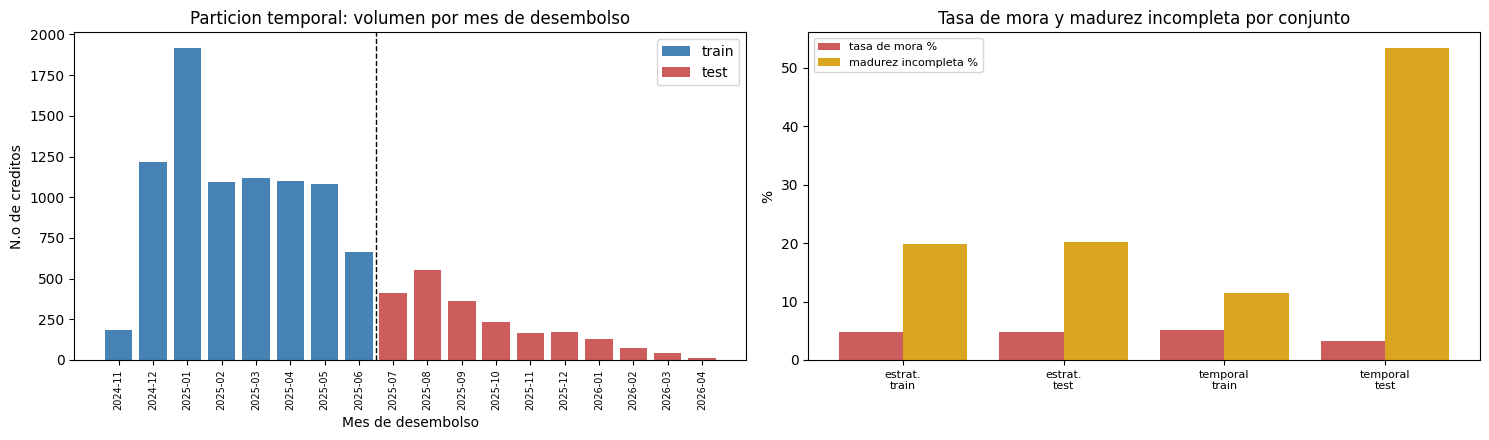

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# --- Distribucion temporal de la particion temporal ---
ax = axes[0]
for datos, etiqueta, color in [(tr_t, 'train', 'steelblue'), (te_t, 'test', 'indianred')]:
    mensual = datos.groupby(datos[fe.COLUMNA_FECHA].dt.to_period('M')).size()
    ax.bar([str(p) for p in mensual.index], mensual.values, label=etiqueta, color=color)
ax.axvline(x=7.5, color='black', linestyle='--', linewidth=1)
ax.set_title('Particion temporal: volumen por mes de desembolso')
ax.set_xlabel('Mes de desembolso'); ax.set_ylabel('N.o de creditos')
ax.tick_params(axis='x', rotation=90, labelsize=7); ax.legend()

# --- Tasa de mora y madurez en cada particion ---
ax = axes[1]
etiquetas = ['estrat.\ntrain', 'estrat.\ntest', 'temporal\ntrain', 'temporal\ntest']
mora = [met_e['mora_train_pct'], met_e['mora_test_pct'],
        met_t['mora_train_pct'], met_t['mora_test_pct']]
madurez = [met_e['madurez_incompleta_train_pct'], met_e['madurez_incompleta_test_pct'],
           met_t['madurez_incompleta_train_pct'], met_t['madurez_incompleta_test_pct']]
x = np.arange(len(etiquetas))
ax.bar(x - 0.2, mora, 0.4, label='tasa de mora %', color='indianred')
ax.bar(x + 0.2, madurez, 0.4, label='madurez incompleta %', color='goldenrod')
ax.set_xticks(x); ax.set_xticklabels(etiquetas, fontsize=8)
ax.set_title('Tasa de mora y madurez incompleta por conjunto')
ax.set_ylabel('%'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### ANALISIS DE LA PARTICION

**La estratificación funciona.** El desvío de la tasa de mora frente al dataset original es de
0,003 y 0,010 puntos porcentuales.

La partición temporal muestra un fenómeno Su test
tiene 3,20% de mora frente al 5,13% del train. La segunda barra del gráfico derecho explica por
qué la **madurez incompleta pasa de 11,5% en train a 53,4% en test**.

No es que el riesgo haya bajado. Es que más de la mitad de los créditos del test aún no vencen y
no ha transcurrido tiempo suficiente para observar el impago.entonces La tasa observada subestima la
real

## Atributos derivados

Todas las operaciones de este paso son **fila a fila**: no dependen de ningún estadístico agregado,
por lo que se aplican idénticamente a train y test sin riesgo de fuga. Se ejecutan **después** de
la partición por disciplina, para que el orden del pipeline sea el mismo que correrá en producción.

| Atributo | Justificación (Fase 1) |
|---|---|
| `consultas_por_credito` | IV 0,1637 — el derivado más predictivo, por encima de `huella_consulta` (0,1455) del que procede |
| `discrepancia_ingresos` | IV 0,0930 — brecha entre ingreso declarado y reportado por el buró |
| `antiguedad_dias` | La tasa de mora varía entre 1,72% y 9,09% según el mes |
| `mes_prestamo`, `trimestre_prestamo` | Componentes de estacionalidad |
| `tipo_credito_grp` | Los tipos 7 y 68 tienen 2 y 1 registro: no son estimables como categorías propias |

In [6]:
conjuntos = {
    'estratificado': (fe.construir_derivadas(tr_e, FECHA_CORTE_OBS),
                      fe.construir_derivadas(te_e, FECHA_CORTE_OBS)),
    'temporal':      (fe.construir_derivadas(tr_t, FECHA_CORTE_OBS),
                      fe.construir_derivadas(te_t, FECHA_CORTE_OBS)),
}

nuevas = ['consultas_por_credito', 'discrepancia_ingresos', 'antiguedad_dias',
          'mes_prestamo', 'trimestre_prestamo', 'tipo_credito_grp']

tr, te = conjuntos['estratificado']
print("Atributos construidos:\n")
print(tr[nuevas].describe().round(3).to_string())

Atributos construidos:

       consultas_por_credito  discrepancia_ingresos  antiguedad_dias  mes_prestamo  trimestre_prestamo
count               8610.000           6.263000e+03         8610.000      8610.000            8610.000
mean                   0.775           2.083743e+06          375.097         5.260               2.101
std                    0.726           2.540091e+06          103.585         3.721               1.128
min                    0.000           0.000000e+00            0.000         1.000               1.000
25%                    0.333           3.988235e+05          314.000         2.000               1.000
50%                    0.600           1.250000e+06          396.000         4.000               2.000
75%                    1.000           2.850588e+06          461.000         8.000               3.000
max                   15.000           3.610658e+07          516.000        12.000               4.000


## Binning y Weight 

### Por qué WoE y no One-Hot

El dominio es riesgo crediticio, donde **la interpretabilidad es un requisito regulatorio**donde hay
que justificar la negación de un crédito ante el cliente y ante el supervisor. El WoE produce un
único coeficiente por variable cuyo signo y magnitud se leen directamente como nivel de riesgo.

Además **resuelve los nulos sin imputar**. La ausencia de dato se trata como una categoría más,
con su WoE estimado a partir de su tasa observada. Los 153 clientes sin score y los 2.930 sin
reporte de ingresos entran al modelo sin que nadie decida un valor por ellos  lo que valida
retroactivamente la decisión de la Fase 1 de no fabricar esos valores.

$$WoE_{tramo} = \ln\left(\frac{\% \text{ eventos del tramo}}{\% \text{ no eventos del tramo}}\right)$$

WoE positivo indica más riesgo que el promedio de la cartera.

### Criterio de fusión de tramos

Un tramo con pocos registros produce un WoE inestable que el modelo memoriza como ruido. **Caso
concreto de este proyecto:** la banda de score por debajo de 600 puntos tiene 25 registros y una
tasa de mora del 64%, lo que generaría un WoE de +3,57 apoyado en 16 eventos.

El script fusiona automáticamente los tramos que no alcanzan **5% de la población o 20 eventos de
mora**. La categoría `SIN_DATO` nunca se fusiona: la ausencia de dato no es un valor alto ni bajo,
y mezclarla con un tramo numérico destruiría su interpretación.

> **Todo lo que sigue se ajusta ÚNICAMENTE sobre `train`.**

In [7]:
y_train = 1 - tr[fe.TARGET]

receta = fe.ajustar_binning(tr, y_train)

print(f"Criterio: min {fe.MIN_POBLACION_BIN:.0%} de poblacion o {fe.MIN_EVENTOS_BIN} eventos por tramo")
print(f"Suavizado de Laplace: {fe.SUAVIZADO}\n")
for col, spec in receta.items():
    print(f"  {col:32s} {spec['tipo']:11s} {len(spec['woe'])} tramos | IV = {spec['iv']:.4f}")

Criterio: min 5% de poblacion o 20 eventos por tramo
Suavizado de Laplace: 0.5

  puntaje_datacredito              numerica    6 tramos | IV = 0.1898
  plazo_meses                      numerica    4 tramos | IV = 0.0904
  huella_consulta                  numerica    5 tramos | IV = 0.1129
  consultas_por_credito            numerica    5 tramos | IV = 0.1148
  promedio_ingresos_datacredito    numerica    6 tramos | IV = 0.1044
  discrepancia_ingresos            numerica    6 tramos | IV = 0.0788
  edad_cliente                     numerica    5 tramos | IV = 0.0717
  cant_creditosvigentes            numerica    5 tramos | IV = 0.0191
  tipo_laboral                     categorica  2 tramos | IV = 0.0157
  tendencia_ingresos               categorica  4 tramos | IV = 0.0486
  tipo_credito_grp                 categorica  5 tramos | IV = 0.0580


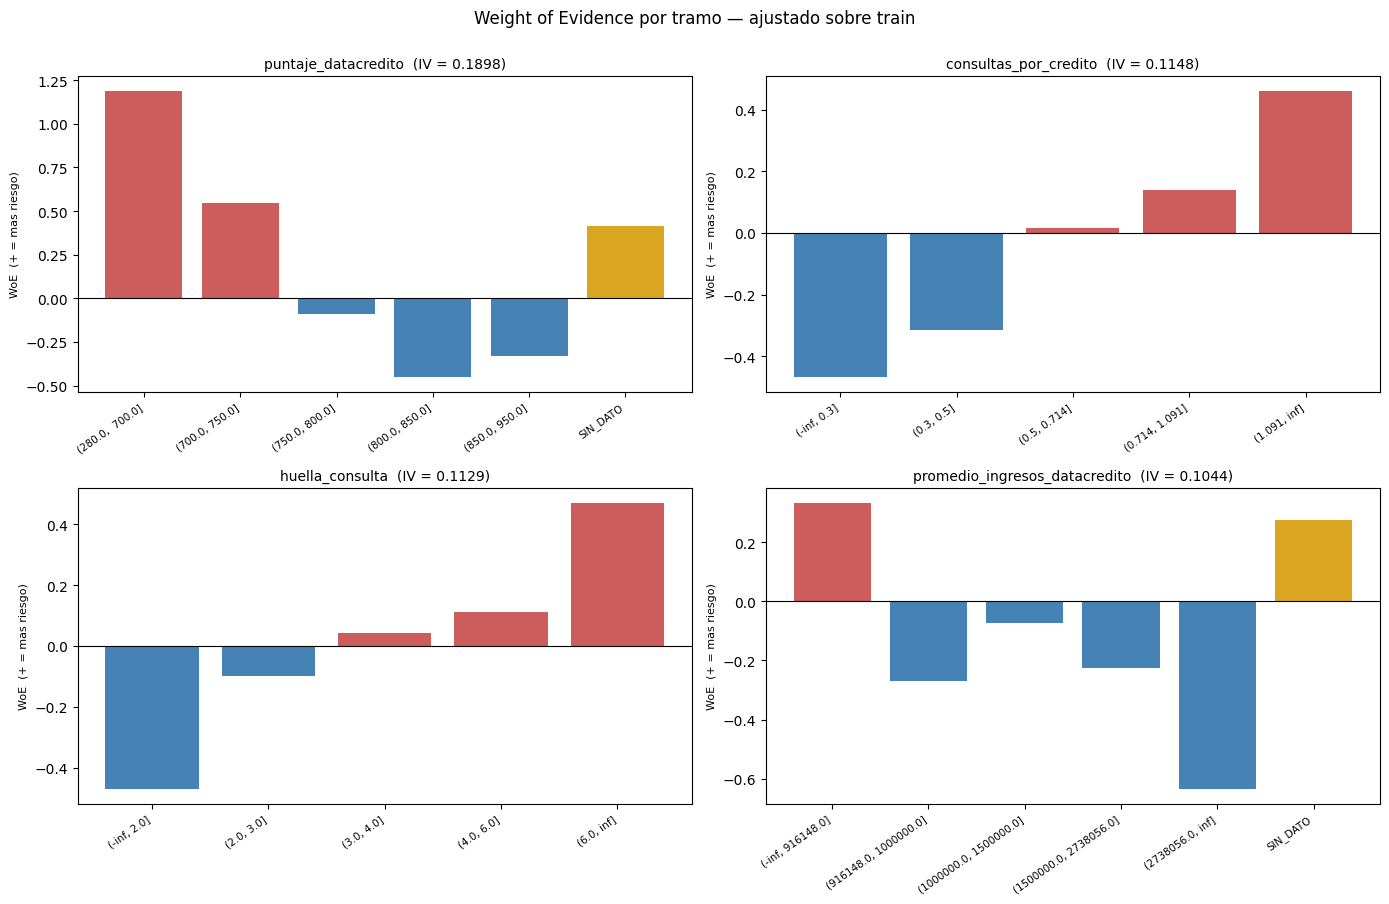

In [8]:
# Visualizacion del WoE de las cuatro variables de mayor Information Value
top = sorted(receta.items(), key=lambda kv: -kv[1]['iv'])[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (col, spec) in zip(axes.flatten(), top):
    tramos = list(spec['woe'].keys())
    numericos = [t for t in tramos if t != fe.ETIQUETA_NULO]
    if spec['tipo'] == 'numerica':
        numericos.sort(key=lambda s: float(s.split(',')[0].strip('([ ')))
    orden = numericos + ([fe.ETIQUETA_NULO] if fe.ETIQUETA_NULO in tramos else [])
    valores = [spec['woe'][t] for t in orden]
    colores = ['indianred' if v > 0 else 'steelblue' for v in valores]
    # SIN_DATO se distingue: no es un tramo del rango, es ausencia de informacion
    if fe.ETIQUETA_NULO in orden:
        colores[-1] = 'goldenrod'
    ax.bar(range(len(orden)), valores, color=colores)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(range(len(orden)))
    ax.set_xticklabels(orden, rotation=35, ha='right', fontsize=7.5)
    ax.set_title(f'{col}  (IV = {spec["iv"]:.4f})', fontsize=10)
    ax.set_ylabel('WoE  (+ = mas riesgo)', fontsize=8)
plt.suptitle('Weight of Evidence por tramo — ajustado sobre train', y=1.00)
plt.tight_layout(); plt.show()

### Analisis del WoE

**`puntaje_datacredito`** produce el gradiente más limpio: de **+1,190** en la banda más baja a
**−0,453** en la de 800–850. La barra dorada es `SIN_DATO`, que se ubica sola en **+0,416**, entre
las bandas de 700–750 y 750–800. Nadie decidió esa posición: la determinó su tasa observada.

**`plazo_meses`** confirma el hallazgo de la Fase 1 que el análisis inicial había descartado el
tramo de 24–90 meses alcanza **+1,016**, frente a valores negativos en los plazos cortos.



Dos variables no son monótonas y **no se forzaron los cortes** para que lo fueran:

- **`plazo_meses`**: el tramo de 0–6 meses tiene más mora que el de 6–12. Ya estaba documentado en
  el EDA (4,76% frente a 3,91%).
- **`puntaje_datacredito`**: la banda superior (850–950) tiene un WoE ligeramente mayor que la de
  800–850.

Forzar monotonía aquí produciría un modelo más elegante pero menos fiel a los datos. Se documenta
la excepción en lugar de maquillarla.

## Codificación y escalado

**Monetarias** (`capital_prestado`, `cuota_pactada`, `salario_cliente`, `total_otros_prestamos`):
`log1p` seguido de **escalado robusto** (mediana e IQR).

Se descarta la estandarización clásica porque la Fase 1 midió asimetrías de 2,2 a 38,5 en estas
variables: la media y la desviación estándar quedan dominadas por la cola derecha, de modo que el
resultado no estaría realmente centrado. La mediana y el IQR no se ven afectados por los extremos.

**Categóricas**: WoE sobre sus niveles. **Binarias**: pasan sin transformar, ya están en 0/1.

In [9]:
parametros = fe.ajustar_escalado(tr)
print("Parametros de escalado (aprendidos SOLO en train):\n")
for col, p in parametros.items():
    print(f"  {col:24s} mediana log1p = {p['mediana']:7.3f} | IQR = {p['iqr']:.3f}")

# Ensamblaje de la matriz final: la receta de train se APLICA a test, no se reajusta
m_tr = fe.ensamblar_matriz(tr, receta, parametros)
m_te = fe.ensamblar_matriz(te, receta, parametros)

print(f"\nMatriz de caracteristicas: train {m_tr.shape} | test {m_te.shape}")
print(f"Columnas identicas y en el mismo orden: {list(m_tr.columns) == list(m_te.columns)}")
print(f"Nulos en la matriz: train {m_tr.isna().sum().sum()} | test {m_te.isna().sum().sum()}")
m_tr.head(3)

Parametros de escalado (aprendidos SOLO en train):

  capital_prestado         mediana log1p =  14.465 | IQR = 0.918
  cuota_pactada            mediana log1p =  12.114 | IQR = 0.856
  salario_cliente          mediana log1p =  14.914 | IQR = 0.811
  total_otros_prestamos    mediana log1p =  13.816 | IQR = 1.386



Matriz de caracteristicas: train (8610, 26) | test (2153, 26)
Columnas identicas y en el mismo orden: True
Nulos en la matriz: train 0 | test 0


,woe_puntaje_datacredito,woe_plazo_meses,woe_huella_consulta,woe_consultas_por_credito,woe_promedio_ingresos_datacredito,woe_discrepancia_ingresos,woe_edad_cliente,woe_cant_creditosvigentes,woe_tipo_laboral,woe_tendencia_ingresos,woe_tipo_credito_grp,esc_capital_prestado,esc_cuota_pactada,esc_salario_cliente,esc_total_otros_prestamos,promedio_ingresos_datacredito_era_nulo,sin_historial_crediticio,edad_cliente_corregida,salario_cliente_corregido,tendencia_ingresos_reconstruida,total_otros_prestamos_sospechoso,mes_prestamo,trimestre_prestamo,antiguedad_dias,madurez_incompleta,Pago_atiempo
10268,-0.090153,-0.179471,-0.470764,0.462204,-0.072927,-0.544489,-0.238008,0.115470,-0.101731,-0.207167,-0.026201,-0.793463,-1.220251,-1.237223,-0.868482,0,0,0,0,0,0,1,1,461,0,1
6674,-0.452602,-0.179471,-0.470764,-0.313716,0.274181,0.274181,-0.238008,0.115470,-0.101731,0.275582,0.010930,0.378243,0.386594,-0.629925,-0.014573,1,0,0,0,0,0,7,3,290,0,1
10411,0.544303,-0.179471,-0.470764,-0.468919,0.274181,0.274181,-0.238008,-0.134332,-0.101731,0.275582,0.010930,-0.101222,-0.345277,1.484681,1.160965,1,0,0,0,0,0,1,1,476,0,1


##  Validación del aporte de las características

Tres comprobaciones: que el IV se conserve al reducir tramos, que no haya indicios de fuga, y que
las características transformadas superen a las originales en un modelo real.


El Information Value **crece mecánicamente con el número de tramos** más tramos permiten ajustarse
mejor a los datos de entrenamiento, aunque parte de ese ajuste sea ruido. Comparar la versión final
(4–6 tramos) contra una de 10 la penalizaría sin motivo real.

Por eso se reportan dos referencias: el **IV bruto** con 10 tramos (cuánta señal hay si se permite
sobreajustar) y la **retención**, que mide cuánto de esa señal se conserva tras la fusión.

In [10]:
validacion = fe.validar_features(tr, receta, y_train)
ranking = validacion['ranking']

print("=== Ranking por Information Value ===\n")
print(ranking[['variable', 'iv_bruto_10tramos', 'iv_transformada',
               'retencion_vs_bruto', 'n_tramos', 'woe_monotono']].to_string(index=False))

print(f"\nRetencion media de IV: {ranking['retencion_vs_bruto'].dropna().mean():.0%} "
      f"usando {ranking['n_tramos'].mean():.1f} tramos de media (frente a 10)")

if validacion['alertas']:
    print("\n=== Alertas ===")
    for a in validacion['alertas']:
        print("  -", a)

=== Ranking por Information Value ===

                     variable  iv_bruto_10tramos  iv_transformada  retencion_vs_bruto  n_tramos woe_monotono
          puntaje_datacredito             0.1979           0.1898               0.959         6        False
        consultas_por_credito             0.1344           0.1148               0.854         5         True
              huella_consulta             0.1470           0.1129               0.768         5         True
promedio_ingresos_datacredito             0.1133           0.1044               0.921         6        False
                  plazo_meses             0.1279           0.0904               0.707         4        False
        discrepancia_ingresos             0.0862           0.0788               0.914         6         True
                 edad_cliente             0.0741           0.0717               0.968         5        False
             tipo_credito_grp             0.0580           0.0580               1.000    

-- APLICACION DE UN MODELO BASELINE BASADO EN HEURISITCAS

In [11]:
baseline = fe.baseline_comparativo(m_tr, crudo_train=tr)

print("=== Baseline: regresion logistica, 5-fold estratificado, metrica AUC-PR ===\n")
print(f"  Variables ORIGINALES  : {baseline['originales']['auc_pr_media']:.4f} "
      f"+/- {baseline['originales']['auc_pr_desv']:.4f}  ({baseline['originales']['n_features']} features)")
print(f"  Variables TRANSFORMADAS: {baseline['transformadas']['auc_pr_media']:.4f} "
      f"+/- {baseline['transformadas']['auc_pr_desv']:.4f}  ({m_tr.shape[1]-1} features)")
print(f"\n  Tasa base (azar)      : {baseline['tasa_base']:.4f}")
print(f"  Lift sobre el azar    : {baseline['lift_vs_azar']:.2f}x")
print(f"  Ganancia vs originales: {baseline['ganancia_abs']:+.4f} ({baseline['ganancia_rel']*100:+.1f}%)")

=== Baseline: regresion logistica, 5-fold estratificado, metrica AUC-PR ===

  Variables ORIGINALES  : 0.1197 +/- 0.0137  (21 features)
  Variables TRANSFORMADAS: 0.1462 +/- 0.0198  (25 features)

  Tasa base (azar)      : 0.0475
  Lift sobre el azar    : 3.08x
  Ganancia vs originales: +0.0265 (+22.1%)


### Por qué AUC-PR y no exactitud ni AUC-ROC

Con 4,75% de eventos, un modelo que prediga siempre "paga" acierta el 95,25% sin aportar nada: la
**exactitud queda descartada**. El AUC-ROC tampoco sirve bien aquí, porque premia la clasificación
correcta de la clase mayoritaria y resulta excesivamente optimista con clases desbalanceadas.

El **AUC-PR** (precisión-exhaustividad promedio) se concentra en la clase minoritaria, que es
justamente la que interesa detectar. Su referencia de azar es la tasa base, no 0,5.

El escalado va **dentro del pipeline** de validación cruzada, para que se ajuste en cada pliegue de
entrenamiento y no en el de validación. Hacerlo fuera sería fuga.

### Resultado

Las características transformadas superan a las originales en **ambas particiones**
(+22,1% estratificada, +21,0% temporal), con un lift de aproximadamente **3x sobre el azar**. Eso
confirma que el trabajo de esta fase aporta información y no solo reordena la existente.

## Verificación de ausencia de fuga

La comprobación decisiva de toda la fase: demostrar que la receta aprendida **no depende en
absoluto** del conjunto de prueba. La prueba consiste en alterar radicalmente el test y verificar
que la receta no cambia.

In [ ]:
# 1) Se altera el test de forma extrema
te_alterado = te.copy()
te_alterado['puntaje_datacredito'] = 300
te_alterado[fe.TARGET] = 0

# 2) Se reajusta la receta con el MISMO train
receta_2 = fe.ajustar_binning(tr, y_train)
identica = (json.dumps(receta, sort_keys=True, default=str) ==
            json.dumps(receta_2, sort_keys=True, default=str))
print(f"1. La receta es identica pese al test alterado : {identica}")

# 3) Todo WoE aplicado a test debe provenir del mapa de train
woe_test = set(np.round(m_te['woe_puntaje_datacredito'].unique(), 6))
woe_train = set(np.round(list(receta['puntaje_datacredito']['woe'].values()), 6))
# El 0.0 corresponde a niveles no vistos en train: decision conservadora
print(f"2. Todo WoE de test proviene del mapa de train : {woe_test.issubset(woe_train | {0.0})}")

# 4) Ninguna variable con fuga sobrevive en la matriz final
prohibidas = ['saldo_mora', 'saldo_total', 'saldo_principal', 'mora_previa']
presentes = [c for c in m_tr.columns
             if any(p in c.lower() for p in prohibidas)]
print(f"3. Variables con fuga en la matriz final       : {presentes if presentes else 'ninguna'}")

# 5) Ningun IV sospechosamente alto
iv_max = ranking['iv_transformada'].max()
print(f"4. IV maximo = {iv_max:.4f} (umbral de sospecha de fuga: 0.5)")



1. La receta es identica pese al test alterado : True
2. Todo WoE de test proviene del mapa de train : True
3. Variables con fuga en la matriz final       : ninguna
4. IV maximo = 0.1898 (umbral de sospecha de fuga: 0.5)

VERIFICACION DE FUGA SUPERADA


## Fase 2



| Artefacto | Contenido |
|---|---|
| `*_train.csv` / `*_test.csv` | Datos particionados, con las derivadas construidas |
| `*_features.csv` | Matrices transformadas listas para modelar (25 características) |
| `receta_*.json` | **Cortes, fusiones y valores WoE** — el artefacto reutilizable |
| `reporte_features.json` | Ranking de IV, alertas y resultados del baseline |
| `split_metadata.json` | Semilla, tamaños, tasas y variables excluidas |

En la Fase 4, el modelo
en producción debe aplicar exactamente estas transformaciones. Si se recalcularan sobre datos
nuevos, los cortes irían cambiando con el tiempo y el modelo dejaría de ser el que se validó una
fuente de deriva silenciosa.

### Decisiones que quedan abiertas para la Fase 3

1. **Qué partición usar como referencia.** La estratificada tiene 102 casos de mora en test frente
   a 69 de la temporal, y no está afectada por el sesgo de madurez. Propuesta: estratificada como
   referencia principal, temporal como prueba de estrés.
2. **Qué hacer con la madurez incompleta.** El 53,4% del test temporal tiene etiqueta provisional.
   Debe evaluarse con y sin esos registros.
3. **Dos variables de IV bajo.** `cant_creditosvigentes` (0,019) y `tipo_laboral` (0,016) están por
   debajo del umbral. Se conservan porque una variable débil puede aportar en combinación, pero son
   las primeras candidatas a descarte.

 La unidad de observación es el crédito, de modo que un mismo
cliente puede aparecer en train y en test sin que sea posible detectarlo. No se puede aplicar un
split agrupado, y debe declararse al reportar las métricas.
